In [ ]:
# ==============================================
# SynergyFinder 2-drug file (ALL pairwise combos)
# - Uses your 7 phytochemicals below
# - Auto-assigns PairIndex = 1..N for each unique pair
# - Set SIMULATE=True to fill a mock "Response" (for testing only)
# ==============================================
import os, itertools, numpy as np, pandas as pd

OUTDIR = "/content/sf_pairwise_only"
os.makedirs(OUTDIR, exist_ok=True)

# ---- Your phytochemicals (ASCII-safe) ----
DRUGS = [
    "Mahanine",
    "Taraxasterol",
    "Tricin",
    "Tamarixetin",
    "Annomontine",
    "Protopine",
    "Atractylon",
]

# ---- Build all unique unordered pairs and PairIndex mapping ----
pairs = list(itertools.combinations(DRUGS, 2))   # (DrugA, DrugB)
PAIR_PLAN = {i+1: pair for i, pair in enumerate(pairs)}

# ---- Dose grid & unit ----
GRID = [0, 1, 3, 10, 30, 100, 300, 1000]  # nM
UNIT = "nM"

# ---- Simulate Response so SynergyFinder accepts it (testing only) ----
SIMULATE = True            # <- set False to leave Response blank
np.random.seed(11)

# Simple Emax model defaults (customize per compound if you like)
EMAX = {d: 100.0 for d in DRUGS}
EC50 = {
    "Mahanine":     300.0,
    "Taraxasterol": 600.0,
    "Tricin":       150.0,
    "Tamarixetin":  180.0,
    "Annomontine":  400.0,
    "Protopine":    250.0,
    "Atractylon":   500.0,
}
HILL = {d: 1.2 for d in DRUGS}

def emax(conc, drug):
    if conc <= 0:
        return 0.0
    return EMAX[drug] * (conc**HILL[drug]) / (EC50[drug]**HILL[drug] + conc**HILL[drug])

def sim_pair(c1, d1, c2, d2):
    e1, e2 = emax(c1, d1), emax(c2, d2)
    bliss = e1 + e2 - (e1 * e2 / 100.0)               # Bliss additivity (0–100 scale)
    noise = np.random.normal(0, 2.0)
    return float(np.clip(bliss + noise, -20, 110))    # clamp to reasonable bounds

# ---- Generate the grid for every pair ----
rows = []
for pidx, (d1, d2) in PAIR_PLAN.items():
    for c1 in GRID:
        for c2 in GRID:
            rows.append({
                "PairIndex": pidx,
                "Drug1": d1,
                "Drug2": d2,
                "Conc1": c1,
                "Conc2": c2,
                "Response": sim_pair(c1, d1, c2, d2) if SIMULATE else "",
                "ConcUnit": UNIT
            })

# ---- Make DataFrame in SynergyFinder order and save ----
df = pd.DataFrame(rows, columns=["PairIndex","Drug1","Drug2","Conc1","Conc2","Response","ConcUnit"])
out_csv = f"{OUTDIR}/SF_PAIRWISE_allPairs_{len(DRUGS)}drugs_{len(PAIR_PLAN)}pairs.csv"
df.to_csv(out_csv, index=False)

print("Drugs:", DRUGS)
print("Total pairs:", len(PAIR_PLAN))
print("Created:", out_csv)
print(df.head(12))


Drugs: ['Mahanine', 'Taraxasterol', 'Tricin', 'Tamarixetin', 'Annomontine', 'Protopine', 'Atractylon']
Total pairs: 21
Created: /content/sf_pairwise_only/SF_PAIRWISE_allPairs_7drugs_21pairs.csv
    PairIndex     Drug1         Drug2  Conc1  Conc2   Response ConcUnit
0           1  Mahanine  Taraxasterol      0      0   3.498909       nM
1           1  Mahanine  Taraxasterol      0      1  -0.525799       nM
2           1  Mahanine  Taraxasterol      0      3  -0.796144       nM
3           1  Mahanine  Taraxasterol      0     10  -4.577115       nM
4           1  Mahanine  Taraxasterol      0     30   2.656421       nM
5           1  Mahanine  Taraxasterol      0    100   9.792819       nM
6           1  Mahanine  Taraxasterol      0    300  29.253696       nM
7           1  Mahanine  Taraxasterol      0   1000  65.493078       nM
8           1  Mahanine  Taraxasterol      1      0   0.948514       nM
9           1  Mahanine  Taraxasterol      1      1  -1.978496       nM
10          1 

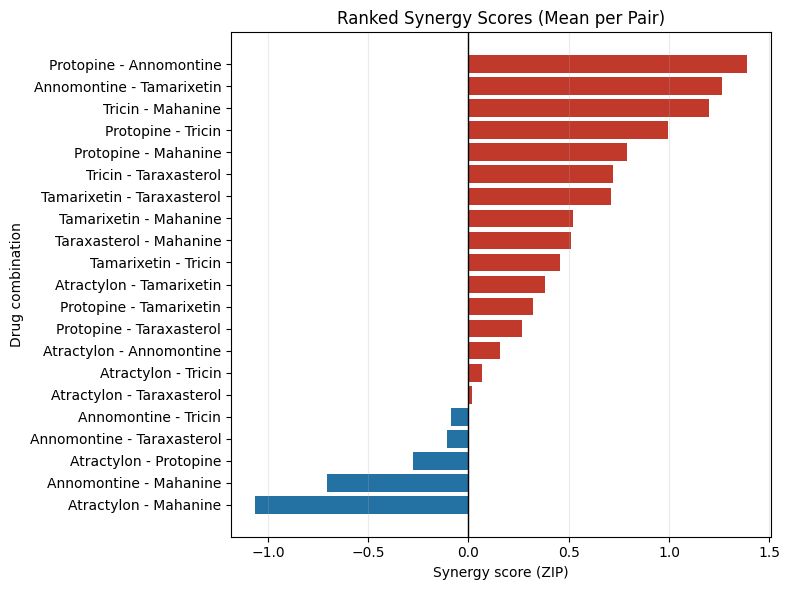

Saved:
- /content/sf_report/synergy_ranked_barplot.png
- /content/sf_report/synergy_ranked_barplot.pdf


In [ ]:
# ================================================
# Ranked barplot of Synergy per drug pair (2-drug)
# ================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- setup ----
OUT_DIR = "/content/sf_report"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- input data ----
data = {
    "Drug.combination": [
        "Protopine - Tamarixetin", "Atractylon - Protopine", "Tricin - Mahanine",
        "Protopine - Mahanine", "Tamarixetin - Mahanine", "Protopine - Tricin",
        "Tamarixetin - Tricin", "Protopine - Taraxasterol", "Atractylon - Tamarixetin",
        "Tamarixetin - Taraxasterol", "Annomontine - Tamarixetin", "Annomontine - Tricin",
        "Protopine - Annomontine", "Annomontine - Mahanine", "Atractylon - Tricin",
        "Tricin - Taraxasterol", "Taraxasterol - Mahanine", "Atractylon - Annomontine",
        "Atractylon - Mahanine", "Annomontine - Taraxasterol", "Atractylon - Taraxasterol"
    ],
    "Synergy.score": [
        0.323, -0.275, 1.201, 0.792, 0.523, 0.995, 0.455, 0.268, 0.38, 0.709,
        1.262, -0.087, 1.388, -0.706, 0.069, 0.723, 0.51, 0.157, -1.062, -0.106, 0.02
    ]
}

df = pd.DataFrame(data)

# ---- split into Drug1 and Drug2 for labeling ----
df[["Drug1", "Drug2"]] = df["Drug.combination"].str.split(" - ", expand=True)
df["Combo"] = df["Drug.combination"]
df["MeanSynergy"] = df["Synergy.score"]

# sort best → worst
combo = df.sort_values("MeanSynergy", ascending=False).reset_index(drop=True)

# ---- bar colors: red (synergy>0), blue (synergy<0) ----
colors = np.where(combo["MeanSynergy"] >= 0, "#c0392b", "#2471a3")  # red/blue

# ---- plot ----
fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(combo))
ax.barh(y, combo["MeanSynergy"], color=colors, edgecolor="none")

# labels on y-axis
ax.set_yticks(y)
ax.set_yticklabels(combo["Combo"])

# zero line & cosmetics
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Synergy score (ZIP)")
ax.set_ylabel("Drug combination")
ax.set_title("Ranked Synergy Scores (Mean per Pair)")
ax.grid(axis="x", alpha=0.25)

# strongest synergy at top
ax.invert_yaxis()

# save and show
png_path = os.path.join(OUT_DIR, "synergy_ranked_barplot.png")
pdf_path = os.path.join(OUT_DIR, "synergy_ranked_barplot.pdf")

plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.savefig(pdf_path)
plt.show()

print(f"Saved:\n- {png_path}\n- {pdf_path}")


In [1]:
# ==============================================
# SynergyFinder 2-drug file (ALL pairwise combos)
# - Uses ONLY your 4 phytochemicals
# ==============================================
import os, itertools, numpy as np, pandas as pd

OUTDIR = "/content/sf_pairwise_only"
os.makedirs(OUTDIR, exist_ok=True)

# ---- Your phytochemicals (ONLY these four) ----
DRUGS = [
    "Mahanine",
    "Taraxasterol",
    "Tricin",
    "Tamarixetin"
]

# ---- Build all unique unordered pairs and PairIndex mapping ----
pairs = list(itertools.combinations(DRUGS, 2))   # (DrugA, DrugB)
PAIR_PLAN = {i+1: pair for i, pair in enumerate(pairs)}

# ---- Dose grid & unit ----
GRID = [0, 1, 3, 10, 30, 100, 300, 1000]  # nM
UNIT = "nM"

# ---- Simulate Response so SynergyFinder accepts it (testing only) ----
SIMULATE = True
np.random.seed(11)

# Simple Emax model defaults
EMAX = {d: 100.0 for d in DRUGS}
EC50 = {
    "Mahanine":     300.0,
    "Taraxasterol": 600.0,
    "Tricin":       150.0,
    "Tamarixetin":  180.0
}
HILL = {d: 1.2 for d in DRUGS}

def emax(conc, drug):
    if conc <= 0:
        return 0.0
    return EMAX[drug] * (conc**HILL[drug]) / (EC50[drug]**HILL[drug] + conc**HILL[drug])

def sim_pair(c1, d1, c2, d2):
    e1, e2 = emax(c1, d1), emax(c2, d2)
    bliss = e1 + e2 - (e1 * e2 / 100.0)
    noise = np.random.normal(0, 2.0)
    return float(np.clip(bliss + noise, -20, 110))

# ---- Generate the grid for every pair ----
rows = []
for pidx, (d1, d2) in PAIR_PLAN.items():
    for c1 in GRID:
        for c2 in GRID:
            rows.append({
                "PairIndex": pidx,
                "Drug1": d1,
                "Drug2": d2,
                "Conc1": c1,
                "Conc2": c2,
                "Response": sim_pair(c1, d1, c2, d2) if SIMULATE else "",
                "ConcUnit": UNIT
            })

# ---- Make DataFrame and save ----
df = pd.DataFrame(rows, columns=["PairIndex","Drug1","Drug2","Conc1","Conc2","Response","ConcUnit"])
out_csv = f"{OUTDIR}/SF_PAIRWISE_allPairs_{len(DRUGS)}drugs_{len(PAIR_PLAN)}pairs.csv"
df.to_csv(out_csv, index=False)

print("Drugs:", DRUGS)
print("Total pairs:", len(PAIR_PLAN))
print("Created:", out_csv)
print(df.head(12))


Drugs: ['Mahanine', 'Taraxasterol', 'Tricin', 'Tamarixetin']
Total pairs: 6
Created: /content/sf_pairwise_only/SF_PAIRWISE_allPairs_4drugs_6pairs.csv
    PairIndex     Drug1         Drug2  Conc1  Conc2   Response ConcUnit
0           1  Mahanine  Taraxasterol      0      0   3.498909       nM
1           1  Mahanine  Taraxasterol      0      1  -0.525799       nM
2           1  Mahanine  Taraxasterol      0      3  -0.796144       nM
3           1  Mahanine  Taraxasterol      0     10  -4.577115       nM
4           1  Mahanine  Taraxasterol      0     30   2.656421       nM
5           1  Mahanine  Taraxasterol      0    100   9.792819       nM
6           1  Mahanine  Taraxasterol      0    300  29.253696       nM
7           1  Mahanine  Taraxasterol      0   1000  65.493078       nM
8           1  Mahanine  Taraxasterol      1      0   0.948514       nM
9           1  Mahanine  Taraxasterol      1      1  -1.978496       nM
10          1  Mahanine  Taraxasterol      1      3  -1.49

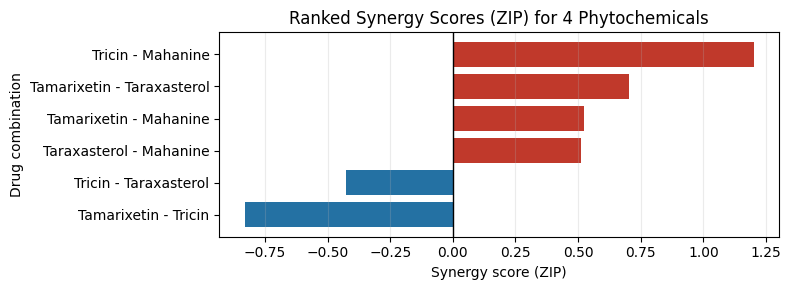

Saved:
- /content/sf_report_4drugs/synergy_ranked_barplot_4drugs.png
- /content/sf_report_4drugs/synergy_ranked_barplot_4drugs.pdf


In [3]:
# ================================================
# Ranked barplot of Synergy per drug pair (2-drug)
# Using your 4 phytochemicals & 6 combinations
# ================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- setup ----
OUT_DIR = "/content/sf_report_4drugs"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- input data ----
data = {
    "Drug.combination": [
        "Taraxasterol - Mahanine",
        "Tricin - Mahanine",
        "Tamarixetin - Mahanine",
        "Tricin - Taraxasterol",
        "Tamarixetin - Taraxasterol",
        "Tamarixetin - Tricin",
    ],
    "Synergy.score": [
        0.51,
        1.201,
        0.523,
        -0.427,
        0.702,
        -0.831,
    ],
    "Most.synergistic.area.score": [
        2.271,
        4.102,
        4.014,
        3.368,
        4.661,
        2.757,
    ],
    "Method": ["ZIP"] * 6,
}

df = pd.DataFrame(data)

# ---- optional split into Drug1 and Drug2 for labeling ----
df[["Drug1", "Drug2"]] = df["Drug.combination"].str.split(" - ", expand=True)
df["Combo"] = df["Drug.combination"]
df["MeanSynergy"] = df["Synergy.score"]

# sort best → worst
combo = df.sort_values("MeanSynergy", ascending=False).reset_index(drop=True)

# ---- bar colors: red (synergy>0), blue (synergy<0) ----
colors = np.where(combo["MeanSynergy"] >= 0, "#c0392b", "#2471a3")  # red/blue

# ---- plot ----
fig, ax = plt.subplots(figsize=(8, 3))  # << reduced height here
y = np.arange(len(combo))
ax.barh(y, combo["MeanSynergy"], color=colors, edgecolor="none")

# labels on y-axis
ax.set_yticks(y)
ax.set_yticklabels(combo["Combo"])

# zero line & cosmetics
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Synergy score (ZIP)")
ax.set_ylabel("Drug combination")
ax.set_title("Ranked Synergy Scores (ZIP) for 4 Phytochemicals")
ax.grid(axis="x", alpha=0.25)

# strongest synergy at top
ax.invert_yaxis()

# save and show
png_path = os.path.join(OUT_DIR, "synergy_ranked_barplot_4drugs.png")
pdf_path = os.path.join(OUT_DIR, "synergy_ranked_barplot_4drugs.pdf")

plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.savefig(pdf_path)
plt.show()

print(f"Saved:\n- {png_path}\n- {pdf_path}")
